# TCN — RUL Prediction on CMAPSS (PyTorch)

This notebook trains and evaluates a **Temporal Convolutional Network (TCN)**
for Remaining Useful Life (RUL) prediction on all CMAPSS datasets, implemented
in PyTorch using the `pytorch-tcn` package.

It mirrors the methodology of `Vanilla_LSTM.ipynb`:
- engine-grouped 90/10 train/val split,
- piecewise-linear RUL labels,
- RMSE and NASA score evaluation.

Only one fixed configuration of the TCN is trained — no hyperparameter search.
This is intentional: the TCN serves as an *architectural baseline* against the
manual-baseline LSTM, isolating the effect of the architecture from the effect
of tuning.

## Notebook Structure
1. Configuration
2. Imports and reproducibility
3. Dataset and DataLoader
4. Data inspection
5. Evaluation metrics (RMSE + NASA scoring function)
6. Architecture definition
7. Training loop
8. Evaluation and results

> **Prerequisite:** Run `preprocessing.ipynb` first to generate the `.npy`
> files in `preprocessed/`.


## 1. Configuration

In [10]:
# ── Configuration ─────────────────────────────────────────────────────────────

PREPROCESSED_DIR = 'preprocessed/'   # output folder from preprocessing.ipynb
MODELS_DIR       = 'saved_models/'   # weights and history persisted here
MODEL_NAME       = 'TCN'             # used as filename prefix; keeps TCN and
                                     # LSTM artefacts from clobbering each other.

DATASETS         = ['FD001', 'FD002_unified', 'FD002_clustered',
                    'FD003', 'FD004_unified', 'FD004_clustered']

SEED             = 42

# Training hyperparameters
BATCH_SIZE       = 256
EPOCHS           = 100
LEARNING_RATE    = 0.002
VALIDATION_SPLIT = 0.1               # fraction of training data held out for validation

# TCN architecture (Bai et al. 2018 defaults)
N_FILTERS    = 64                    # channels per residual block
KERNEL_SIZE  = 3                     # all dilated convs use this kernel
N_BLOCKS     = 4                     # number of residual blocks (dilations 1,2,4,8)
DROPOUT      = 0.2                   # spatial dropout inside each block

# ──────────────────────────────────────────────────────────────────────────────


## 2. Imports and Reproducibility

In PyTorch, reproducibility requires seeding `torch`, `numpy`, and Python's `random`
separately. We also set `torch.backends.cudnn.deterministic = True` to ensure
deterministic CUDA operations when running on GPU.

In [11]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # I encounter ExitCode: 3, Reason: OMP runtime error in the notebook and this is what I found as the workaround talking with Claude.ai.
# Claude says: "In a research/student context this is fine — the risk of incorrect results it warns about is relevant to heavy parallel numerical computing, not sequential LSTM training on a modest dataset."

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import GroupShuffleSplit, GroupKFold

import pandas as pd


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"Seed            : {SEED}")


PyTorch version : 2.10.0+cpu
Device          : cpu
Seed            : 42


## 3. Dataset and DataLoader

PyTorch's `Dataset` / `DataLoader` pattern handles batching, shuffling, and
multi-worker loading. We wrap the numpy arrays in a lightweight `CMAPSSDataset`
class that converts them to `float32` tensors on demand.

### Engine-grouped train / validation split

The training set is split into train / validation by **holding out engines**,
not random samples. Concretely, we use `sklearn.model_selection.GroupShuffleSplit`
with `engine_ids_train.npy` (saved by `preprocessing.ipynb`) as the grouping
variable, and a fixed `random_state` for reproducibility.

A naive sample-level split (e.g. `random_split` over already-windowed data) is
unsafe here for two reasons:

1. **Window overlap.** With stride 1 and window size $W$, consecutive windows from
   one engine share $W{-}1$ timesteps and have nearly identical RUL labels.
   Random splitting almost always lands such pairs on opposite sides of the
   train/val boundary, so the validation loss measures interpolation between
   already-seen sequences rather than generalisation.

2. **Engine identity.** Per-unit characteristics (initial wear, sensor offsets,
   noise patterns) can be memorised. Because the CMAPSS test set is composed of
   completely held-out engines, the validation set must mirror that protocol
   for its loss to be a faithful proxy for test performance.

This follows the engine-grouped 90/10 protocol used by Costa & Sánchez (2021)
on CMAPSS, and the general principle from Hastie et al., *Elements of
Statistical Learning* §7.10: cross-validation must be applied to the entire
modelling pipeline — held-out samples are carved out *before* any feature
engineering or windowing step that could couple them to the training data.

The same machinery exposes `engine_grouped_kfold(...)` for k-fold CV during
hyperparameter tuning (see §7.x).

The TCN reads tensors as `(batch, timesteps, features)` (NLC layout), which
matches what `DataLoader` produces directly.


In [12]:
class CMAPSSDataset(Dataset):
    """
    Wraps preprocessed CMAPSS numpy arrays into a PyTorch Dataset.

    Each item is a tuple (x, y) where:
        x : FloatTensor of shape (window_size, n_features)
        y : FloatTensor scalar representing the RUL label
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()   # (N, T, F)
        self.y = torch.from_numpy(y).float()   # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def engine_grouped_split(engine_ids, val_fraction=VALIDATION_SPLIT, seed=SEED):
    """
    Single 90/10 engine-grouped train/val split.

    Returns
    -------
    train_idx, val_idx : np.ndarray
        Sample-level indices into the windowed arrays such that the set of
        engines present in `train_idx` is disjoint from those in `val_idx`.

    Why this matters
    ----------------
    Windowed CMAPSS data has two leakage paths under naive random splitting:
      (1) Overlapping windows: with stride 1 and window=W, consecutive samples
          share W-1 timesteps. A random split places near-identical windows
          on both sides, making val loss trivially low.
      (2) Engine identity: per-unit idiosyncrasies (initial wear, sensor
          offsets, noise patterns) can be memorised; the test set is composed
          of completely held-out engines, so the val set must be too.

    Holding out *engines* (groups) at split time fixes both. cf. Costa &
    Sánchez (Attention+LSTM for RUL, 2021) for the same protocol on CMAPSS,
    and Hastie, Tibshirani & Friedman (Elements of Statistical Learning, §7.10)
    for the general principle: cross-validation must be applied to the
    full pipeline, with held-out samples carved out *before* any
    transformation that could couple them to the rest.
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    train_idx, val_idx = next(splitter.split(X=np.zeros(len(engine_ids)),
                                             groups=engine_ids))
    return train_idx, val_idx


def engine_grouped_kfold(engine_ids, n_splits=5):
    """
    Generator yielding (train_idx, val_idx) pairs for engine-grouped K-fold CV.

    Drop-in replacement for `engine_grouped_split` when running k-fold
    hyperparameter search. Note: GroupKFold is deterministic (it does not
    shuffle), so the same engine_ids -> same folds. For shuffled folds,
    swap to StratifiedGroupKFold or a manual permutation of engine ids.

    Usage
    -----
    >>> for fold, (tr, va) in enumerate(engine_grouped_kfold(engine_ids, n_splits=5)):
    ...     train_loader, val_loader = build_loaders_from_indices(full_ds, tr, va)
    ...     # ... train, evaluate, log per-fold metrics ...
    """
    splitter = GroupKFold(n_splits=n_splits)
    yield from splitter.split(X=np.zeros(len(engine_ids)), groups=engine_ids)


def build_loaders_from_indices(full_dataset, train_idx, val_idx,
                               batch_size=BATCH_SIZE):
    """Wrap two index arrays into shuffled-train / non-shuffled-val DataLoaders."""
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def load_dataset(preprocessed_dir, dataset):
    """
    Load numpy arrays from disk and return train/val/test DataLoaders
    alongside feature column names and raw arrays.

    Train/val split is engine-grouped (see `engine_grouped_split`).
    """
    p = os.path.join(preprocessed_dir, dataset)

    X_train_all  = np.load(f'{p}_X_train.npy')
    y_train_all  = np.load(f'{p}_y_train.npy')
    engine_ids   = np.load(f'{p}_engine_ids_train.npy')
    X_test       = np.load(f'{p}_X_test.npy')
    y_test       = np.load(f'{p}_y_test.npy')
    feature_cols = list(np.load(f'{p}_feature_cols.npy'))

    # ── Engine-grouped train/val split ───────────────────────────────────────
    train_idx, val_idx = engine_grouped_split(engine_ids,
                                              val_fraction=VALIDATION_SPLIT,
                                              seed=SEED)

    full_dataset = CMAPSSDataset(X_train_all, y_train_all)
    train_loader, val_loader = build_loaders_from_indices(full_dataset,
                                                          train_idx, val_idx)
    test_loader = DataLoader(CMAPSSDataset(X_test, y_test),
                             batch_size=BATCH_SIZE, shuffle=False)

    # Sanity: engine sets must be disjoint
    train_engines = set(engine_ids[train_idx].tolist())
    val_engines   = set(engine_ids[val_idx].tolist())
    assert train_engines.isdisjoint(val_engines), \
        "Engine leakage between train and val — split is broken."

    raw = {
        'X_train': X_train_all, 'y_train': y_train_all,
        'X_test':  X_test,      'y_test':  y_test,
        'engine_ids':   engine_ids,
        'train_idx':    train_idx,
        'val_idx':      val_idx,
        'train_engines': sorted(train_engines),
        'val_engines':   sorted(val_engines),
        'feature_cols': feature_cols,
    }
    return train_loader, val_loader, test_loader, raw


# ── Load all datasets ─────────────────────────────────────────────────────────
loaders = {}
arrays  = {}

for ds in DATASETS:
    tr_loader, val_loader, te_loader, raw = load_dataset(PREPROCESSED_DIR, ds)
    loaders[ds] = {'train': tr_loader, 'val': val_loader, 'test': te_loader}
    arrays[ds]  = raw

    n_features  = raw['X_train'].shape[2]
    window_size = raw['X_train'].shape[1]
    n_train_eng = len(raw['train_engines'])
    n_val_eng   = len(raw['val_engines'])
    n_train_win = len(raw['train_idx'])
    n_val_win   = len(raw['val_idx'])
    print(f"\n{ds}")
    print(f"  Input shape       : (batch, {window_size}, {n_features})")
    print(f"  Train samples     : {len(raw['X_train'])}  "
          f"-> train batches: {len(tr_loader)}, val batches: {len(val_loader)}")
    print(f"  Engine split      : {n_train_eng} train engines / {n_val_eng} val engines "
          f"({n_train_win} / {n_val_win} windows)")
    print(f"  Test engines      : {len(raw['X_test'])}")
    print(f"  Features ({n_features})    : {raw['feature_cols']}")



FD001
  Input shape       : (batch, 30, 15)
  Train samples     : 17731  -> train batches: 62, val batches: 8
  Engine split      : 90 train engines / 10 val engines (15847 / 1884 windows)
  Test engines      : 100
  Features (15)    : [np.str_('T24'), np.str_('T30'), np.str_('T50'), np.str_('P15'), np.str_('P30'), np.str_('Nf'), np.str_('Nc'), np.str_('Ps30'), np.str_('phi'), np.str_('NRf'), np.str_('NRc'), np.str_('BPR'), np.str_('htBleed'), np.str_('W31'), np.str_('W32')]

FD002_unified
  Input shape       : (batch, 20, 21)
  Train samples     : 48819  -> train batches: 173, val batches: 19
  Engine split      : 234 train engines / 26 val engines (44130 / 4689 windows)
  Test engines      : 259
  Features (21)    : [np.str_('T2'), np.str_('T24'), np.str_('T30'), np.str_('T50'), np.str_('P2'), np.str_('P15'), np.str_('P30'), np.str_('Nf'), np.str_('Nc'), np.str_('epr'), np.str_('Ps30'), np.str_('phi'), np.str_('NRf'), np.str_('NRc'), np.str_('BPR'), np.str_('farB'), np.str_('htBleed

## 4. Data Inspection

Sanity checks before touching the model: NaN presence, value ranges after scaling,
and RUL label distributions.

In [13]:
for ds in DATASETS:
    X_tr = arrays[ds]['X_train']
    y_tr = arrays[ds]['y_train']
    X_te = arrays[ds]['X_test']
    y_te = arrays[ds]['y_test']

    print(f"\n── {ds} ────────────────────────────────────")
    print(f"  NaNs  X_train / X_test : {np.isnan(X_tr).sum()} / {np.isnan(X_te).sum()}")
    print(f"  X_train range : [{X_tr.min():.3f},  {X_tr.max():.3f}]")
    print(f"  X_test  range : [{X_te.min():.3f},  {X_te.max():.3f}]  "
          f"(may exceed [0, 1] — scaler was fit on train only)")
    print(f"  y_train range : [{y_tr.min():.1f}, {y_tr.max():.1f}]  (expected [0, 125])")
    print(f"  y_test  range : [{y_te.min():.1f}, {y_te.max():.1f}]")


── FD001 ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [0.000,  1.000]  (may exceed [0, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [7.0, 145.0]

── FD002_unified ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [0.000,  1.000]  (may exceed [0, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [6.0, 194.0]

── FD002_clustered ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [-0.062,  1.000]  (may exceed [0, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [6.0, 194.0]

── FD003 ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : 

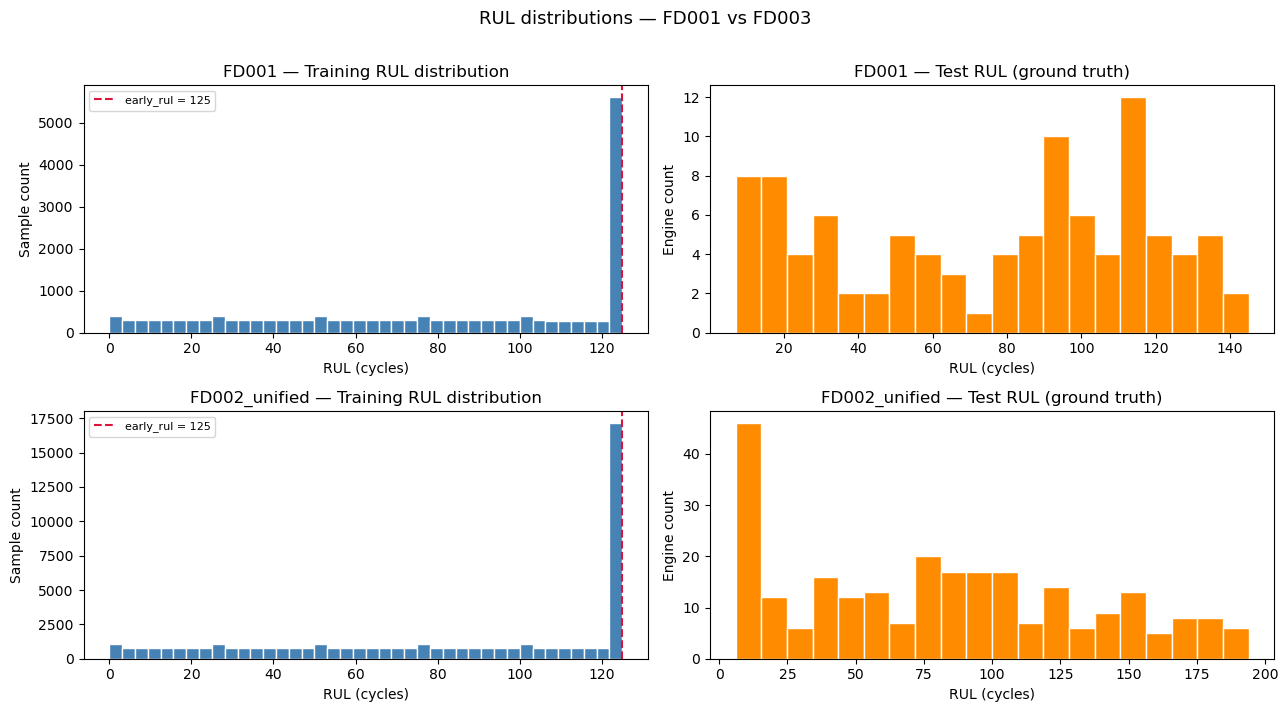

In [14]:
fig, axes = plt.subplots(len(DATASETS[:2]), 2, figsize=(13, 7))

for row, ds in enumerate(DATASETS[:2]):
    y_tr = arrays[ds]['y_train']
    y_te = arrays[ds]['y_test']

    axes[row, 0].hist(y_tr, bins=40, color='steelblue', edgecolor='white')
    axes[row, 0].axvline(125, color='crimson', linestyle='--', label='early_rul = 125')
    axes[row, 0].set_title(f'{ds} — Training RUL distribution')
    axes[row, 0].set_xlabel('RUL (cycles)')
    axes[row, 0].set_ylabel('Sample count')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].hist(y_te, bins=20, color='darkorange', edgecolor='white')
    axes[row, 1].set_title(f'{ds} — Test RUL (ground truth)')
    axes[row, 1].set_xlabel('RUL (cycles)')
    axes[row, 1].set_ylabel('Engine count')

plt.suptitle('RUL distributions — FD001 vs FD003', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, 'rul_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation Metrics

Two standard metrics from the CMAPSS literature are used throughout:

### RMSE
Symmetric, penalises large errors quadratically. Primary benchmark across all papers
including Li et al. (2018) and Da Costa et al. (2019).

From Da Costa et al. (2019) section 3.5 "Loss Function":

$$\mathcal{L}^i(\theta)=||\hat{y}_{t+1}^i - y_{t+1}^i||^2$$

### NASA Asymmetric Scoring Function
Proposed by Saxena et al. (2008) in the original CMAPSS benchmark paper and used
in virtually all subsequent work. Defined as:

$$S = \sum_{i=1}^{N} s_i, \qquad s_i = \begin{cases} e^{-d_i/13} - 1 & d_i < 0 \quad \text{(early prediction)} \\ e^{d_i/10} - 1 & d_i \geq 0 \quad \text{(late prediction)} \end{cases}$$

where $d_i = \hat{y}_i - y_i$. The asymmetry is physically motivated: a late
warning leaves no time to act, so overestimating RUL is penalised more harshly.

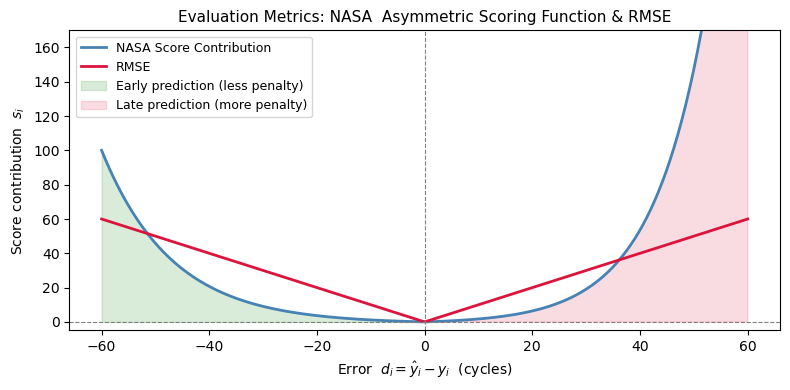

In [15]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def nasa_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    NASA asymmetric scoring function (Saxena et al., 2008).
    Penalises late predictions (d > 0) more harshly than early ones.
    Lower is better.
    """
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1,
                         np.exp( d / 10) - 1)
    return float(np.sum(s))


def evaluate(model: nn.Module, loader: DataLoader):
    """
    Run inference over a DataLoader.
    Returns (y_true, y_pred) as numpy arrays, ready for metric functions.
    Model is set to eval mode and no gradients are computed.
    """
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            output  = model(X_batch).squeeze(-1).cpu().numpy()
            preds.append(output)
            targets.append(y_batch.numpy())

    return np.concatenate(targets), np.concatenate(preds)


# ── Visualise the scoring function shape ──────────────────────────────────────
d_range = np.linspace(-60, 60, 500)
s_vals  = np.where(d_range < 0, np.exp(-d_range / 13) - 1,
                                 np.exp( d_range / 10) - 1)
rmse_vals = np.abs(d_range)  # RMSE contribution is just the absolute error (since it's squared and then rooted, the shape is linear)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(d_range, s_vals, color='steelblue', linewidth=2, label='NASA Score Contribution')
ax.plot(d_range, rmse_vals, color='crimson', linewidth=2, label = "RMSE")
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.fill_between(d_range, s_vals, 0, where=(d_range < 0),
                alpha=0.15, color='green',   label='Early prediction (less penalty)')
ax.fill_between(d_range, s_vals, 0, where=(d_range >= 0),
                alpha=0.15, color='crimson', label='Late prediction (more penalty)')
ax.set_xlabel(r'Error  $d_i = \hat{y}_i - y_i$  (cycles)', fontsize=10)
ax.set_ylabel(r'Score contribution  $s_i$', fontsize=10)
ax.set_title('Evaluation Metrics: NASA  Asymmetric Scoring Function & RMSE', fontsize=11)
ax.set_ylim(-5, 170)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, 'Evaluation_Metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Architecture Definition

### Temporal Convolutional Network (TCN)

The TCN follows Bai et al. (2018), *"An Empirical Evaluation of Generic
Convolutional and Recurrent Networks for Sequence Modeling"*. Key design
choices:

1. **Causal dilated convolutions** — each output at time $t$ depends only on
   inputs at times $\le t$, preserving the temporal order required for RUL
   prediction.
2. **Exponentially increasing dilation** — dilation factor $d = 2^i$ at the
   $i$-th block. This produces an effective receptive field that grows
   exponentially with depth, letting the network reach far back with few
   parameters.
3. **Residual blocks** — each block contains *two* dilated causal conv layers
   with weight normalisation, ReLU activation, and dropout. A 1×1 conv shortcut
   is added when input and output channel counts differ.
4. **Sequence-to-scalar output** — for RUL regression we predict a single value
   per window, taken from the last time-step's channel after a 1×1 projection
   to one output channel.

### Receptive field

For a TCN with $n$ residual blocks (each containing two stacked dilated convs)
and dilations $\{2^i\}_{i=0}^{n-1}$, the receptive field is

$$\text{RF} = 1 + 2(k-1) \sum_{i=0}^{n-1} 2^i = 1 + 2(k-1)(2^n - 1).$$

With our defaults ($k=3$, $n=4$):

$$\text{RF} = 1 + 2 \cdot 2 \cdot (16 - 1) = 61\ \text{time-steps}.$$

This comfortably exceeds the longest input window in the preprocessing pipeline
(30 cycles for FD001/FD003; 20 for FD002/FD004), so each output position
attends to the entire input history.

### Architecture hyperparameters

| Parameter      | Value | Source / rationale |
|----------------|-------|---------------------|
| `kernel_size`  | 3     | Bai et al. default; matches CMAPSS literature |
| `n_blocks`     | 4     | Yields RF = 61 ≥ window size |
| `n_filters`    | 64    | Per-block channel count |
| `dropout`      | 0.2   | Mild regularisation |
| `causal`       | True  | RUL must not depend on future timesteps |
| `weight_norm`  | True  | Stabilises training (Salimans & Kingma, 2016) |


In [16]:
from pytorch_tcn import TCN


def receptive_field(kernel_size: int, n_blocks: int) -> int:
    """RF = 1 + 2*(k-1)*(2^n - 1) for a TCN with two dilated convs per block."""
    return 1 + 2 * (kernel_size - 1) * (2 ** n_blocks - 1)


class TCN_model(nn.Module):
    """
    TCN for RUL regression using `pytorch-tcn`.

    Parameters
    ----------
    input_size  : number of sensor / setting features (per timestep)
    n_filters   : channels in every residual block (constant width)
    kernel_size : kernel size for all dilated convolutions
    n_blocks    : number of residual blocks (dilations 1, 2, 4, ..., 2^(n-1))
    dropout     : dropout probability inside each residual block
    """
    def __init__(self,
                 input_size: int,
                 n_filters: int = N_FILTERS,
                 kernel_size: int = KERNEL_SIZE,
                 n_blocks: int = N_BLOCKS,
                 dropout: float = DROPOUT):
        super().__init__()

        # `num_channels` controls (a) the number of blocks and (b) the channel
        # count of each block's output. Length = n_blocks (NOT n_blocks+1).
        # The first block reads from `num_inputs` and writes to num_channels[0].
        num_channels = [n_filters] * n_blocks

        self.tcn = TCN(
            num_inputs           = input_size,
            num_channels         = num_channels,
            kernel_size          = kernel_size,
            dilations            = None,           # auto: 2^i
            dropout              = dropout,
            causal               = True,
            use_norm             = 'weight_norm',
            activation           = 'relu',
            use_skip_connections = False,
            input_shape          = 'NLC',          # data is (N, T, F)
            output_projection    = 1,              # 1×1 conv to a single output channel
            output_activation    = None,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (N, T, F) — NLC layout
        # With input_shape='NLC' and output_projection=1, the TCN's output
        # is also NLC: (N, T, 1). We want the prediction at the last timestep.
        x = self.tcn(x)            # (N, T, 1)
        x = x[:, -1, :]            # last timestep → (N, 1)
        return x.squeeze(-1)       # (N,)


# ── Instantiate one model per dataset ────────────────────────────────────────
models = {}
for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    set_seed(SEED)                 # deterministic init per model
    model = TCN_model(input_size=n_features).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    models[ds] = {'model': model, 'optimizer': optimizer}


# ── Sanity check: parameters, receptive field vs window size ─────────────────
RF = receptive_field(KERNEL_SIZE, N_BLOCKS)
print(f"TCN receptive field (k={KERNEL_SIZE}, n_blocks={N_BLOCKS}): {RF} timesteps\n")

print(f"  {'dataset':<18} {'window':>6} {'features':>9} {'params':>10} "
      f"{'RF ≥ window':>13}")
print(f"  {'-'*18} {'-'*6} {'-'*9} {'-'*10} {'-'*13}")
for ds, contents in models.items():
    m           = contents['model']
    n_params    = sum(p.numel() for p in m.parameters())
    n_features  = arrays[ds]['X_train'].shape[2]
    window_size = arrays[ds]['X_train'].shape[1]
    ok          = "✓" if RF >= window_size else "✗  (UNDERSIZED)"
    print(f"  {ds:<18} {window_size:>6d} {n_features:>9d} {n_params:>10,} {ok:>13}")


TCN receptive field (k=3, n_blocks=4): 61 timesteps

  dataset            window  features     params   RF ≥ window
  ------------------ ------ --------- ---------- -------------
  FD001                  30        15     91,009             ✓
  FD002_unified          20        21     92,545             ✓
  FD002_clustered        20        21     92,545             ✓
  FD003                  30        16     91,265             ✓
  FD004_unified          20        21     92,545             ✓
  FD004_clustered        20        21     92,545             ✓


In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    """One full pass over the training DataLoader. Returns mean train loss."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()                  # clear gradients from previous step
        preds = model(X_batch).squeeze(-1)     # (batch,)
        loss  = criterion(preds, y_batch)
        loss.backward()                        # compute gradients
        optimizer.step()                       # update weights

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    """Compute mean validation loss without gradient computation."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds   = model(X_batch).squeeze(-1)
            total_loss += criterion(preds, y_batch).item() * len(y_batch)

    return total_loss / len(loader.dataset)


def run_training(model, ds, epochs=EPOCHS, snapshot_epochs=None):
    """
    Full training run for a given dataset key.

    Parameters
    ----------
    model           : the model to train (modified in-place; best weights restored at end)
    ds              : dataset key into `loaders`
    epochs          : total epochs to run
    snapshot_epochs : optional iterable of epoch numbers at which to deep-copy
                      the model's state_dict. Used for diagnostic plots that
                      show predictions evolving across training. Has no effect
                      on training itself.

    Returns
    -------
    train_losses, val_losses : lists, length `epochs`
    snapshots                : dict mapping epoch -> state_dict (empty if snapshot_epochs is None)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None
    snapshots     = {}
    snapshot_set  = set(snapshot_epochs) if snapshot_epochs is not None else set()

    for epoch in range(1, epochs + 1):
        tr_loss  = train_one_epoch(model, loaders[ds]['train'], optimizer, criterion)
        val_loss = validate(model, loaders[ds]['val'], criterion)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch in snapshot_set:
            snapshots[epoch] = {k: v.detach().clone().cpu()
                                for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train MSE: {tr_loss:.4f} | Val MSE: {val_loss:.4f}")

    model.load_state_dict(best_state)
    print(f"\n  Best val MSE : {best_val_loss:.4f}  (best weights restored)")
    return train_losses, val_losses, snapshots


def plot_loss_curves(train_losses, val_losses, ds):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_losses, label='Train MSE', color='steelblue')
    ax.plot(val_losses,   label='Val MSE',   color='darkorange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'{ds} — Training and Validation Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PREPROCESSED_DIR, f'{MODEL_NAME}_{ds}_loss_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


In [18]:
# ── Run training for each dataset ─────────────────────────────────────────────
# The diagnostic snapshot mechanism from Vanilla_LSTM.ipynb is preserved but
# disabled by default for TCN — TCNs do not exhibit the LSTM forget-gate
# plateau, so the constant-prediction-vs-cliff diagnostic loses its purpose
# here. To enable, set e.g. SNAPSHOT_EPOCHS = {'FD001': [10, 30, 50, 100]}.
SNAPSHOT_EPOCHS = {}

train_condition = input("Do you want to overwrite (a possibly) existing model? Yes/No: ")
while train_condition not in ['Yes', 'No']:
    print("Invalid input. Please try again. Yes/No")
    train_condition = input("Do you want to overwrite (a possibly) existing model? Yes/No: ")

TRAIN = (train_condition == 'Yes')

if TRAIN:
    os.makedirs(MODELS_DIR, exist_ok=True)

    histories       = {}   # ds -> (train_losses, val_losses)
    snapshots_by_ds = {}   # ds -> {epoch: state_dict}

    for ds, contents in models.items():
        model = contents['model']

        print(f"\n{'='*55}\n  Training {MODEL_NAME} on {ds}\n{'='*55}")

        train_losses, val_losses, snaps = run_training(
            model, ds, snapshot_epochs=SNAPSHOT_EPOCHS.get(ds))
        plot_loss_curves(train_losses, val_losses, ds)

        histories[ds]       = (train_losses, val_losses)
        snapshots_by_ds[ds] = snaps

        # Save weights / history under MODEL_NAME prefix so TCN and LSTM
        # artefacts coexist on disk.
        save_path    = os.path.join(MODELS_DIR, f'{MODEL_NAME}_{ds}.pt')
        history_path = os.path.join(MODELS_DIR, f'{MODEL_NAME}_{ds}_history.pt')

        torch.save(model.state_dict(), save_path)
        torch.save({'train_losses': train_losses,
                    'val_losses':   val_losses}, history_path)

        if snaps:
            snap_path = os.path.join(MODELS_DIR, f'{MODEL_NAME}_{ds}_snapshots.pt')
            torch.save(snaps, snap_path)
            print(f"  Saved snapshots → {snap_path}  ({sorted(snaps.keys())})")

        print(f"  Saved weights → {save_path}")
        print(f"  Saved history → {history_path}")
else:
    raise Exception("Execution stopped. We do not desire to train a model and "
                    "the rest of the notebook has to not execute")



  Training TCN on FD001
  Epoch   1/100 | Train MSE: 2016.7949 | Val MSE: 601.6606


KeyboardInterrupt: 

## 8. Evaluation and Results

Test-set RMSE and NASA score for each dataset, computed from the
best-validation-loss checkpoint saved during training. Mirrors the evaluation
procedure used in `Vanilla_LSTM.ipynb` so the two architectures can be
compared directly on identical test sets.


In [ ]:
# ── RMSE and NASA score on test set ──────────────────────────────────────────
results = []   # list of dicts → DataFrame at the end

for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = TCN_model(input_size=n_features).to(DEVICE)
    model.load_state_dict(
        torch.load(os.path.join(MODELS_DIR, f'{MODEL_NAME}_{ds}.pt'),
                   map_location=DEVICE)
    )

    y_true, y_pred = evaluate(model, loaders[ds]['test'])

    results.append({
        'dataset': ds,
        'rmse'   : rmse(y_true, y_pred),
        'score'  : nasa_score(y_true, y_pred),
        # Bias diagnostic — same as discussed for the LSTM analysis.
        # Negative bias = systematically early predictions, which the NASA
        # score rewards.
        'bias'      : float((y_pred - y_true).mean()),
        'mae'       : float(np.abs(y_pred - y_true).mean()),
        'pct_late'  : float((y_pred > y_true).mean()),
    })

results_df = pd.DataFrame(results).set_index('dataset').reindex(DATASETS)
print(f"{MODEL_NAME} — test-set results\n" + "="*60)
print(results_df.round(2).to_string())


### 8.1 Predicted vs True Scatter

Per-dataset scatter of test-set predictions against ground truth. Points
clustering on the diagonal is the goal; systematic bias above or below
indicates over/under-prediction of RUL.

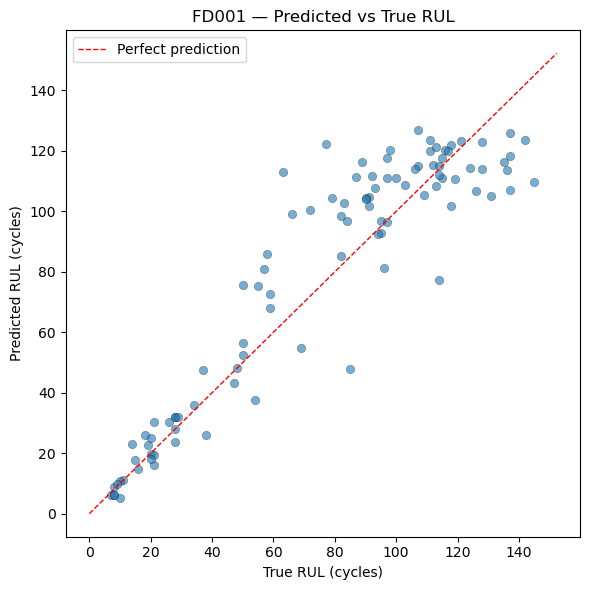

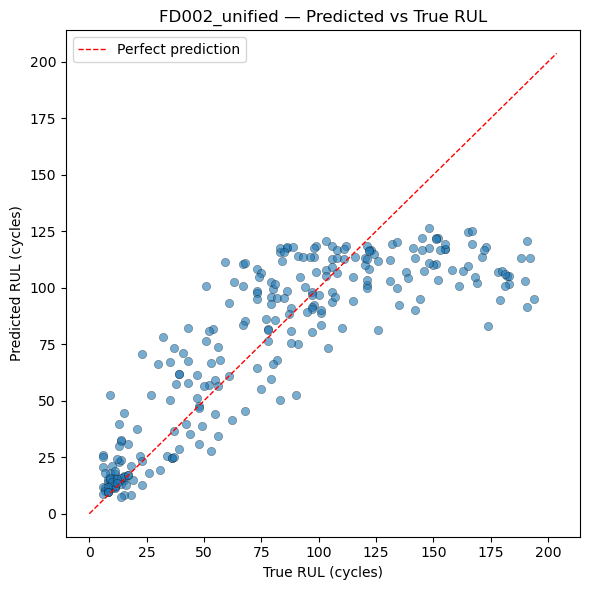

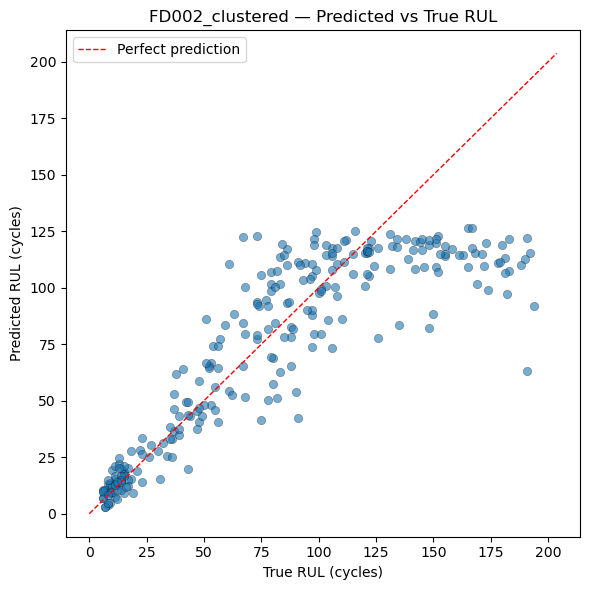

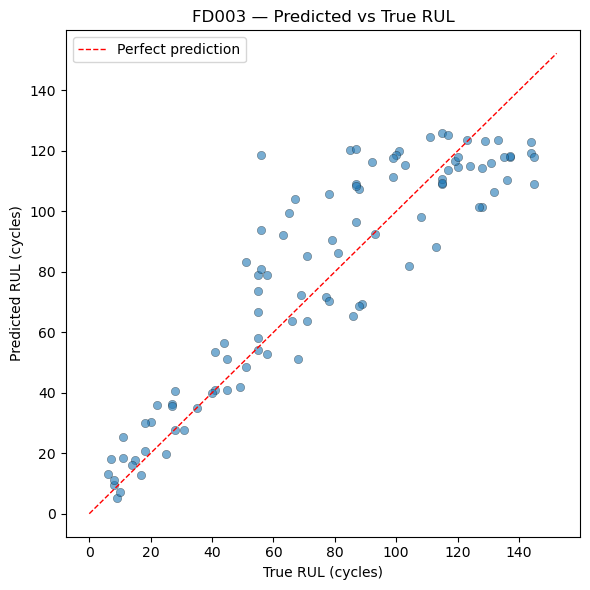

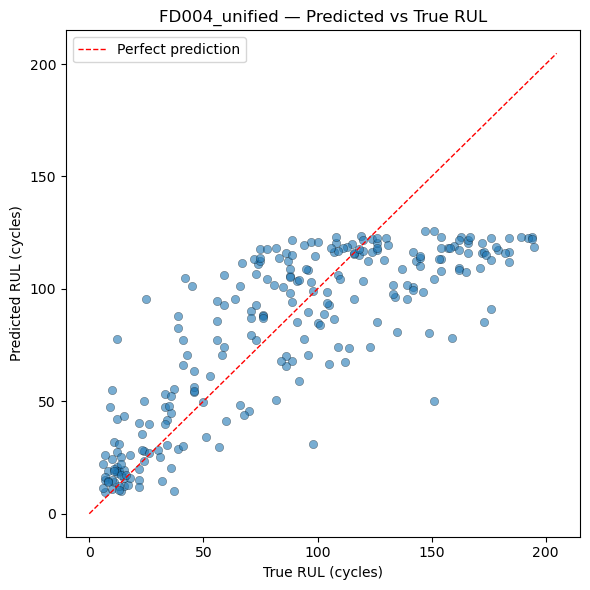

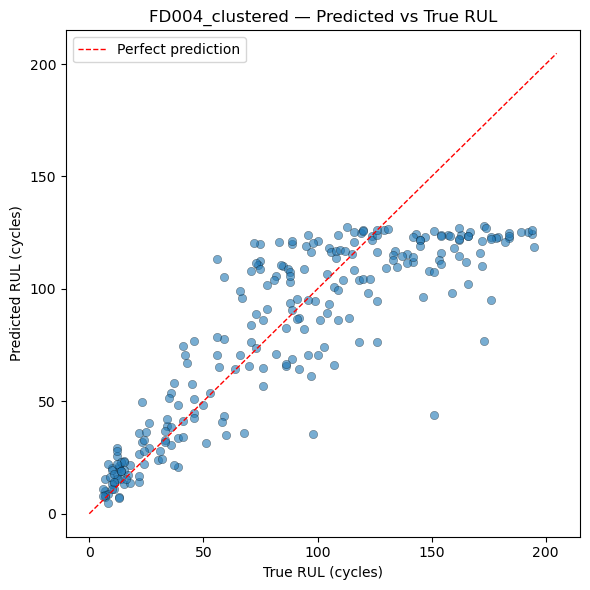

In [ ]:
# ── Predicted vs true RUL scatter ────────────────────────────────────────────
# Points should cluster around the diagonal. Systematic bias above/below
# indicates consistent over/underestimation — penalised differently by NASA score.

for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = TCN_model(input_size=n_features).to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f'{MODEL_NAME}_{ds}.pt'),
                                  map_location=DEVICE))
    y_true, y_pred = evaluate(model, loaders[ds]['test'])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidths=0.3)
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f'{ds} — Predicted vs True RUL')
    ax.legend()
    plt.tight_layout()
    plt.show()